# Project 5 — MOJ Crown Court · **Article 2 visuals (remand: custody vs bail)**

Same house style as `04_visuals.ipynb`, for the second article. Every chart is built
from `gold_remand_age_summary` — no number typed by hand. Run top to bottom; each cell
shows the figure and saves a PNG into `articles/visuals/` (prefixed `a2_`).

## Step 0 — Setup: palette, paths, helpers

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import FancyBboxPatch, Rectangle
from pathlib import Path
import pandas as pd

CREAM="#F4F1E9"; INK="#13273A"; RED="#D12E26"; STEEL="#2E6187"
ROYAL="#1D4ED8"; ORANGE="#E08A1E"; MUTED="#8A94A0"; LABEL="#9AA1AC"
GRID="#E4E1D8"; PANEL="#FBFAF7"; PINK="#F7E7E4"; WHITE="#FFFFFF"
SERIF="DejaVu Serif"; MONO="DejaVu Sans Mono"; SANS="DejaVu Sans"

PROJECT = Path.cwd()
if PROJECT.name == "notebooks": PROJECT = PROJECT.parent
GOLD = PROJECT/"data"/"gold"; OUT = PROJECT/"articles"/"visuals"; OUT.mkdir(parents=True, exist_ok=True)
SRC = "Source: MOJ Criminal Court Statistics Quarterly, Oct\u2013Dec 2025 (One Crown basis)  |  github.com/YusufIsmailayo"
plt.rcParams.update({"font.family":"DejaVu Sans","figure.facecolor":PANEL,"axes.facecolor":PANEL,
    "axes.edgecolor":MUTED,"axes.linewidth":0.8,"text.color":INK,"axes.labelcolor":INK,
    "xtick.color":INK,"ytick.color":INK,"font.size":11})
def frame(ax):
    for s in ["top","right"]: ax.spines[s].set_visible(False)
    ax.grid(axis="y",color=GRID,lw=0.9); ax.set_axisbelow(True)
def head(fig,t,s):
    fig.text(0.075,0.945,t,fontsize=17,fontweight="bold",color=INK,ha="left")
    fig.text(0.075,0.886,s,fontsize=11.5,color=MUTED,ha="left")
def foot(fig): fig.text(0.075,0.03,SRC,fontsize=8.3,color=MUTED,ha="left")

s = pd.read_parquet(GOLD/"gold_remand_age_summary.parquet")
L = s.quarter_end.max(); lat = s[s.quarter_end==L].set_index("remand_status")
print("latest quarter:", L.date())

latest quarter: 2025-12-31


## Chart 1 — The paradox: bail cases age three times as often
Share of open trial cases past a year, custody vs bail.

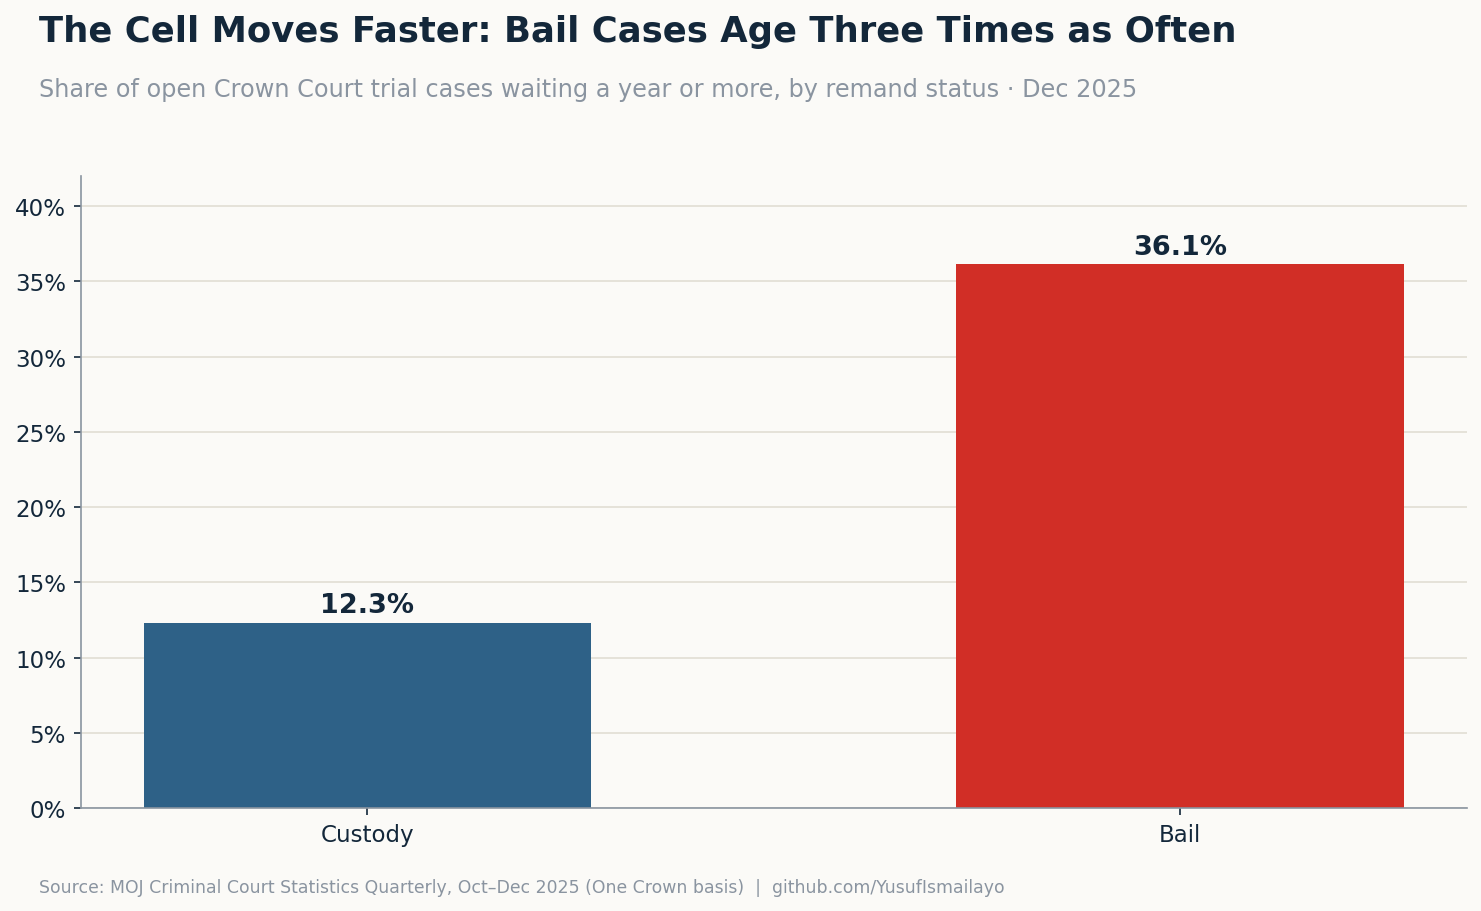

In [5]:
fig,ax=plt.subplots(figsize=(11,6.2),dpi=150); fig.subplots_adjust(top=0.80,bottom=0.12,left=0.10,right=0.94)
vals=[lat.loc["Custody","share_1yr_plus"]*100, lat.loc["Bail","share_1yr_plus"]*100]
bars=ax.bar(["Custody","Bail"],vals,color=[STEEL,RED],width=0.55)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+0.7,f"{v:.1f}%",ha="center",fontsize=13,fontweight="bold",color=INK)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x:.0f}%")); ax.set_ylim(0,42); frame(ax)
head(fig,"The Cell Moves Faster: Bail Cases Age Three Times as Often",
     "Share of open Crown Court trial cases waiting a year or more, by remand status \u00b7 Dec 2025"); foot(fig)
fig.savefig(OUT/"a2_01_share_by_remand.png"); plt.show()

## Chart 2 — Who's in the year-plus pile (87% on bail)

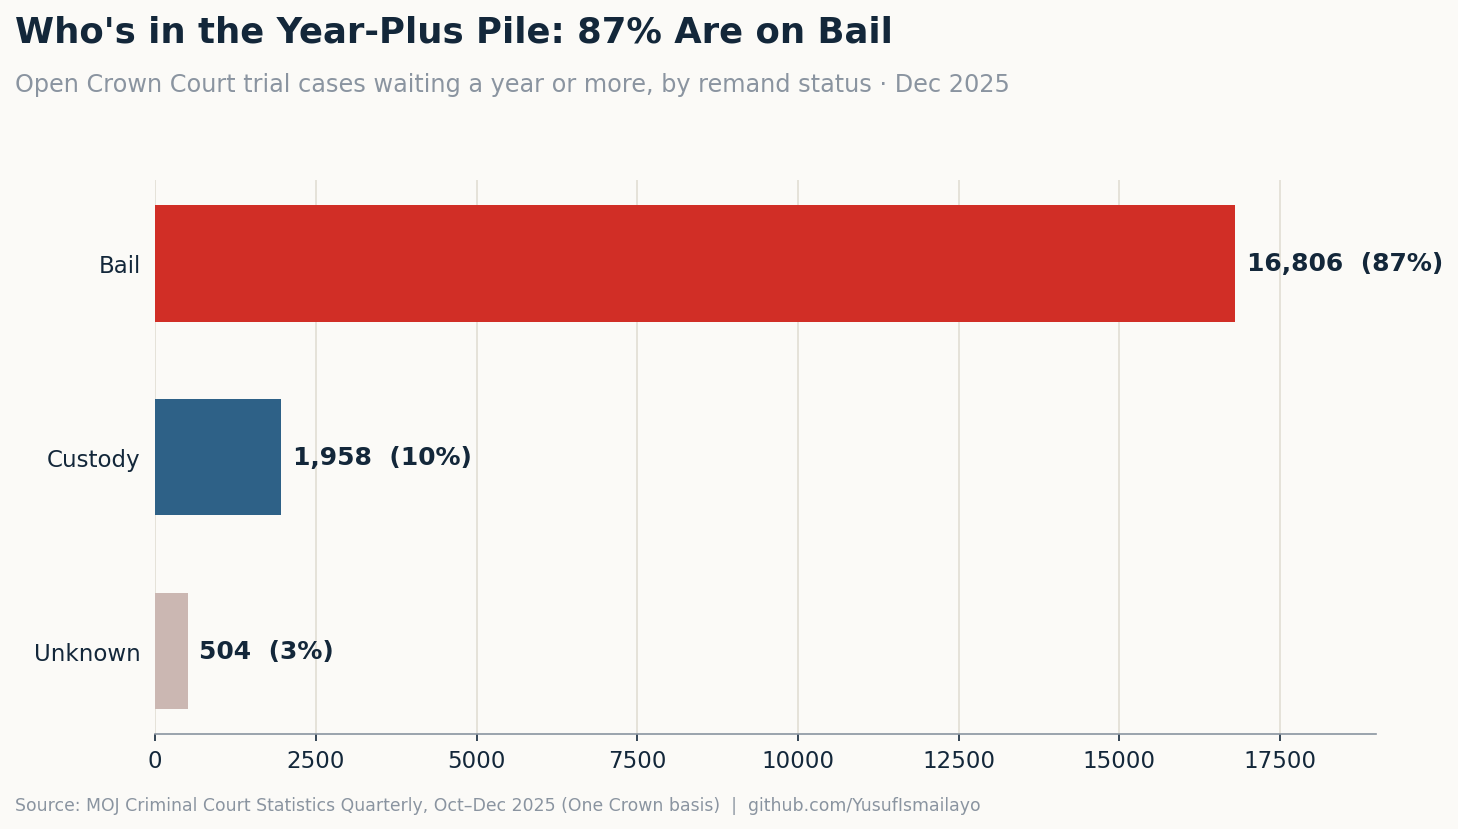

In [7]:
fig,ax=plt.subplots(figsize=(11,5.6),dpi=150); fig.subplots_adjust(top=0.78,bottom=0.12,left=0.16,right=0.90)
order=["Unknown","Custody","Bail"]; counts=[lat.loc[o,"open_1yr_plus"] for o in order]; tot=sum(counts)
bars=ax.barh(order,counts,color=["#CBB7B2",STEEL,RED],height=0.6)
for b,v in zip(bars,counts): ax.text(v+180,b.get_y()+b.get_height()/2,f"{v:,.0f}  ({v/tot:.0%})",va="center",fontsize=12,fontweight="bold",color=INK)
ax.set_xlim(0,19000)
for sp in ["top","right","left"]: ax.spines[sp].set_visible(False)
ax.grid(axis="x",color=GRID,lw=0.9); ax.set_axisbelow(True); ax.tick_params(left=False)
head(fig,"Who's in the Year-Plus Pile: 87% Are on Bail",
     "Open Crown Court trial cases waiting a year or more, by remand status \u00b7 Dec 2025"); foot(fig)
fig.savefig(OUT/"a2_02_aged_caseload_split.png"); plt.show()

## Chart 3 — Both rising, bail running away (2016–2025)

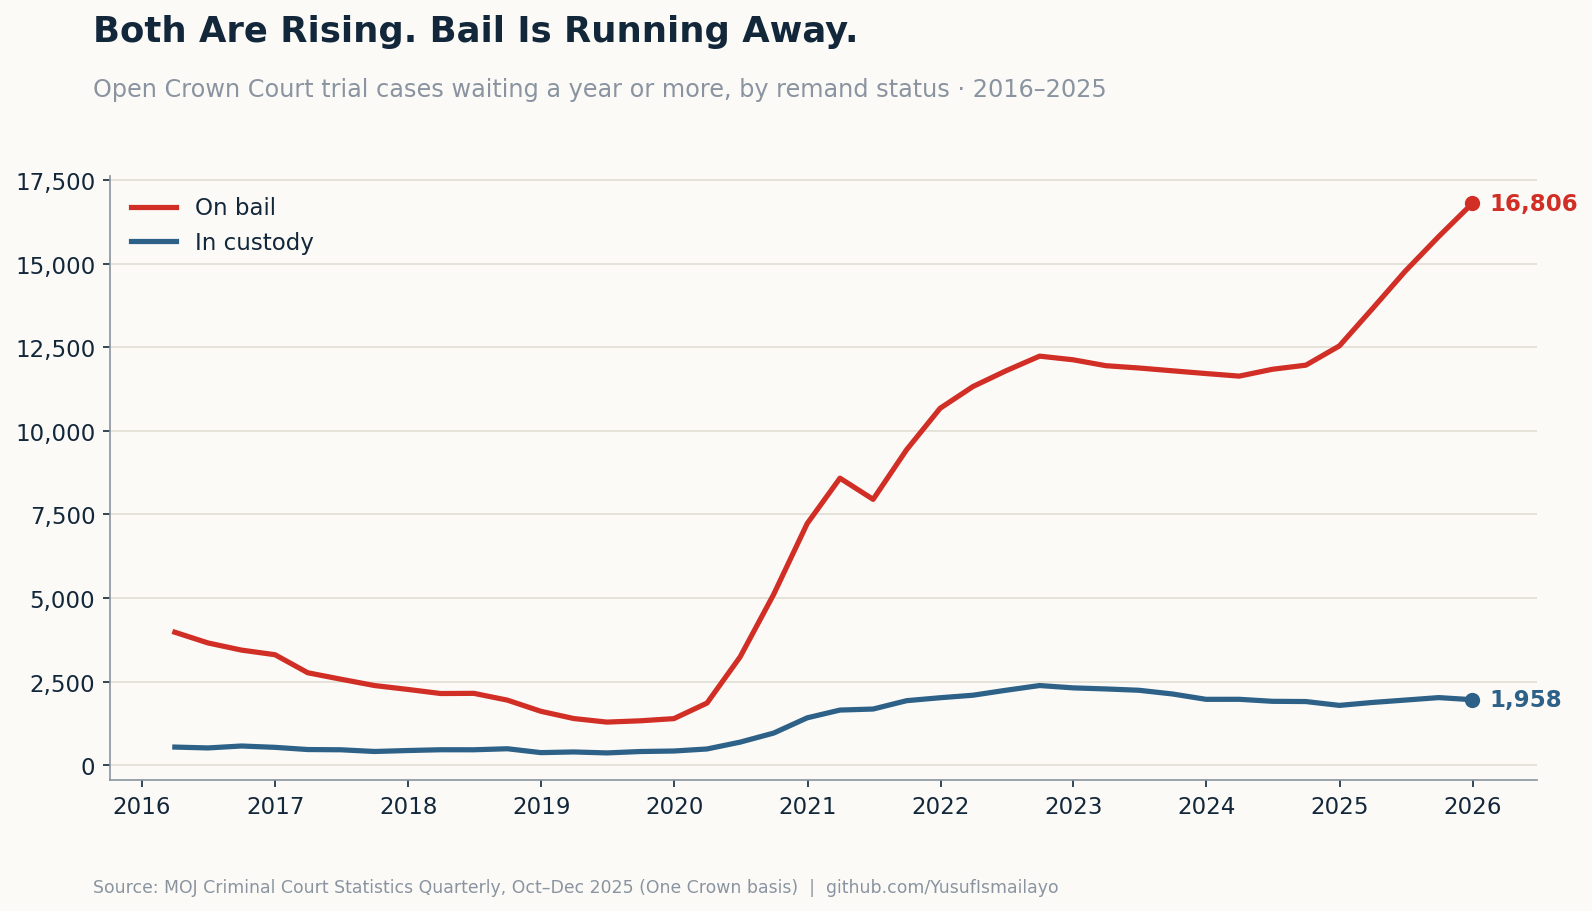

In [9]:
cust=s[s.remand_status=="Custody"].sort_values("quarter_end"); bail=s[s.remand_status=="Bail"].sort_values("quarter_end")
fig,ax=plt.subplots(figsize=(11,6.2),dpi=150); fig.subplots_adjust(top=0.80,bottom=0.15,left=0.085,right=0.95)
ax.plot(bail.quarter_end,bail.open_1yr_plus,color=RED,lw=2.5,label="On bail")
ax.plot(cust.quarter_end,cust.open_1yr_plus,color=STEEL,lw=2.5,label="In custody")
for d,c in [(bail,RED),(cust,STEEL)]:
    last=d.iloc[-1]; ax.scatter([last.quarter_end],[last.open_1yr_plus],color=c,zorder=5,s=40)
    ax.annotate(f"{last.open_1yr_plus:,.0f}",(last.quarter_end,last.open_1yr_plus),xytext=(8,0),textcoords="offset points",va="center",fontsize=11,fontweight="bold",color=c)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(frameon=False,loc="upper left",fontsize=11); frame(ax)
head(fig,"Both Are Rising. Bail Is Running Away.",
     "Open Crown Court trial cases waiting a year or more, by remand status \u00b7 2016\u20132025"); foot(fig)
fig.savefig(OUT/"a2_03_trajectory.png"); plt.show()

## Cover + social cards
"The Cell Moves *Faster.*" — for pixel-perfect Playfair, edit `cover_card_template.html`.

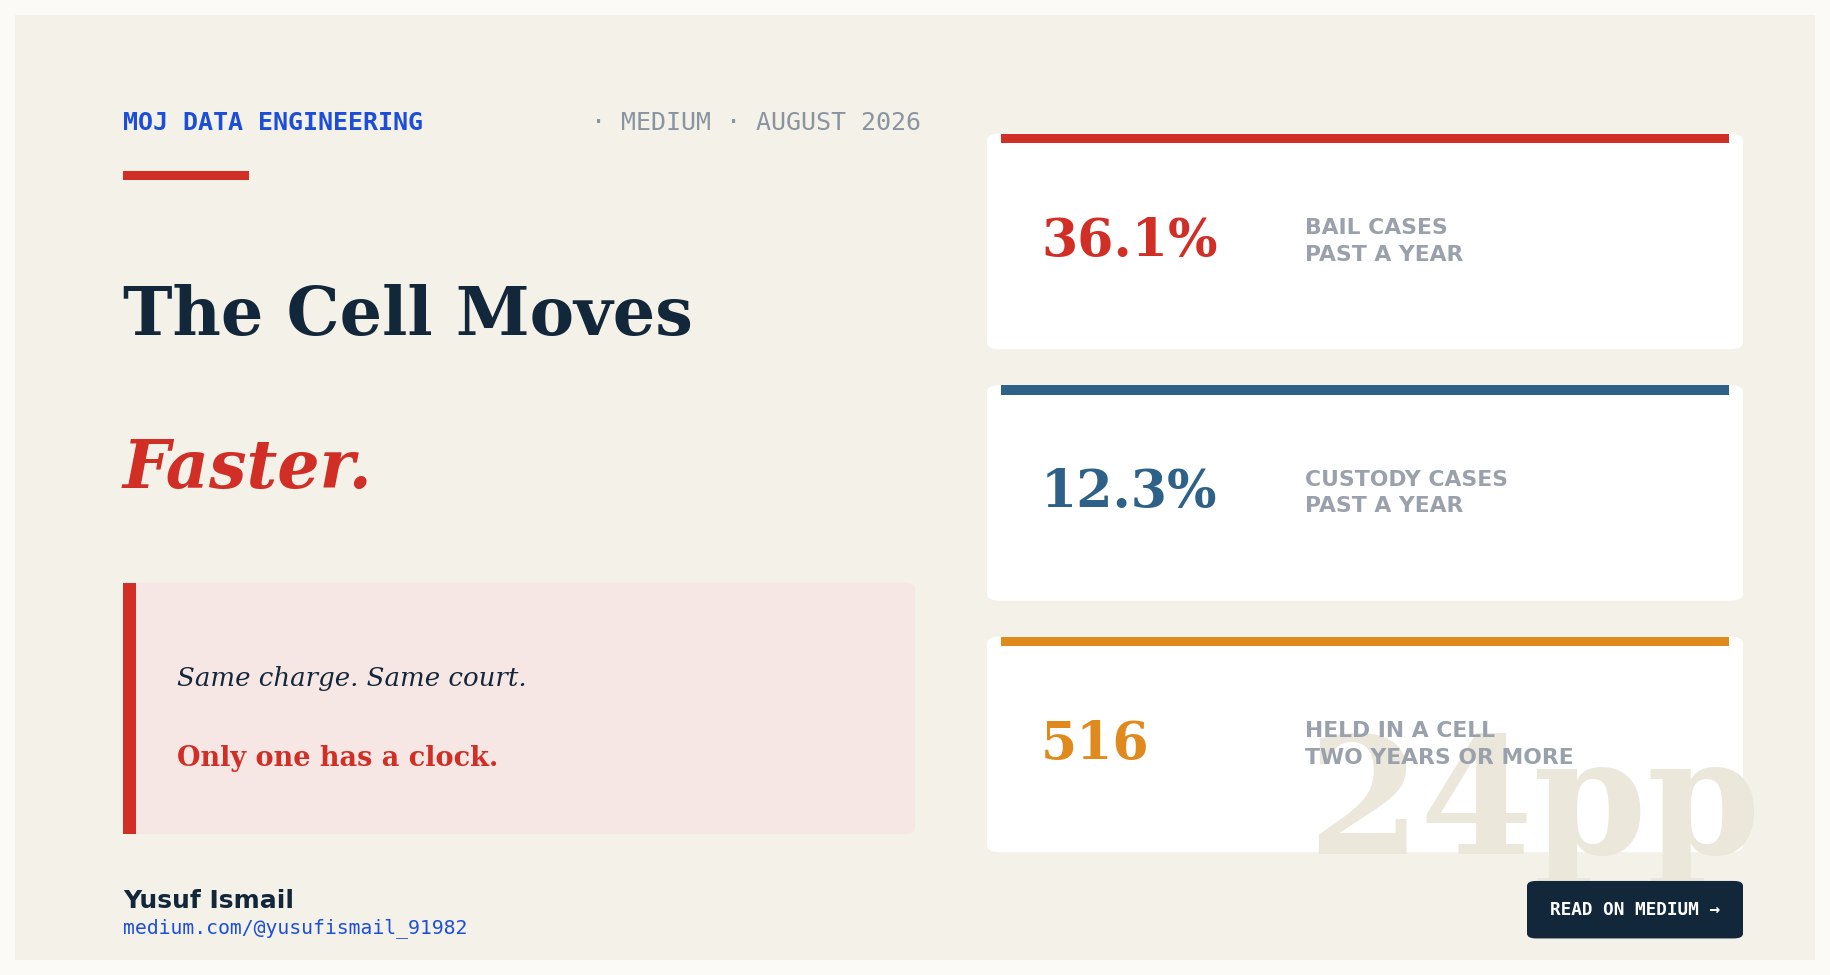

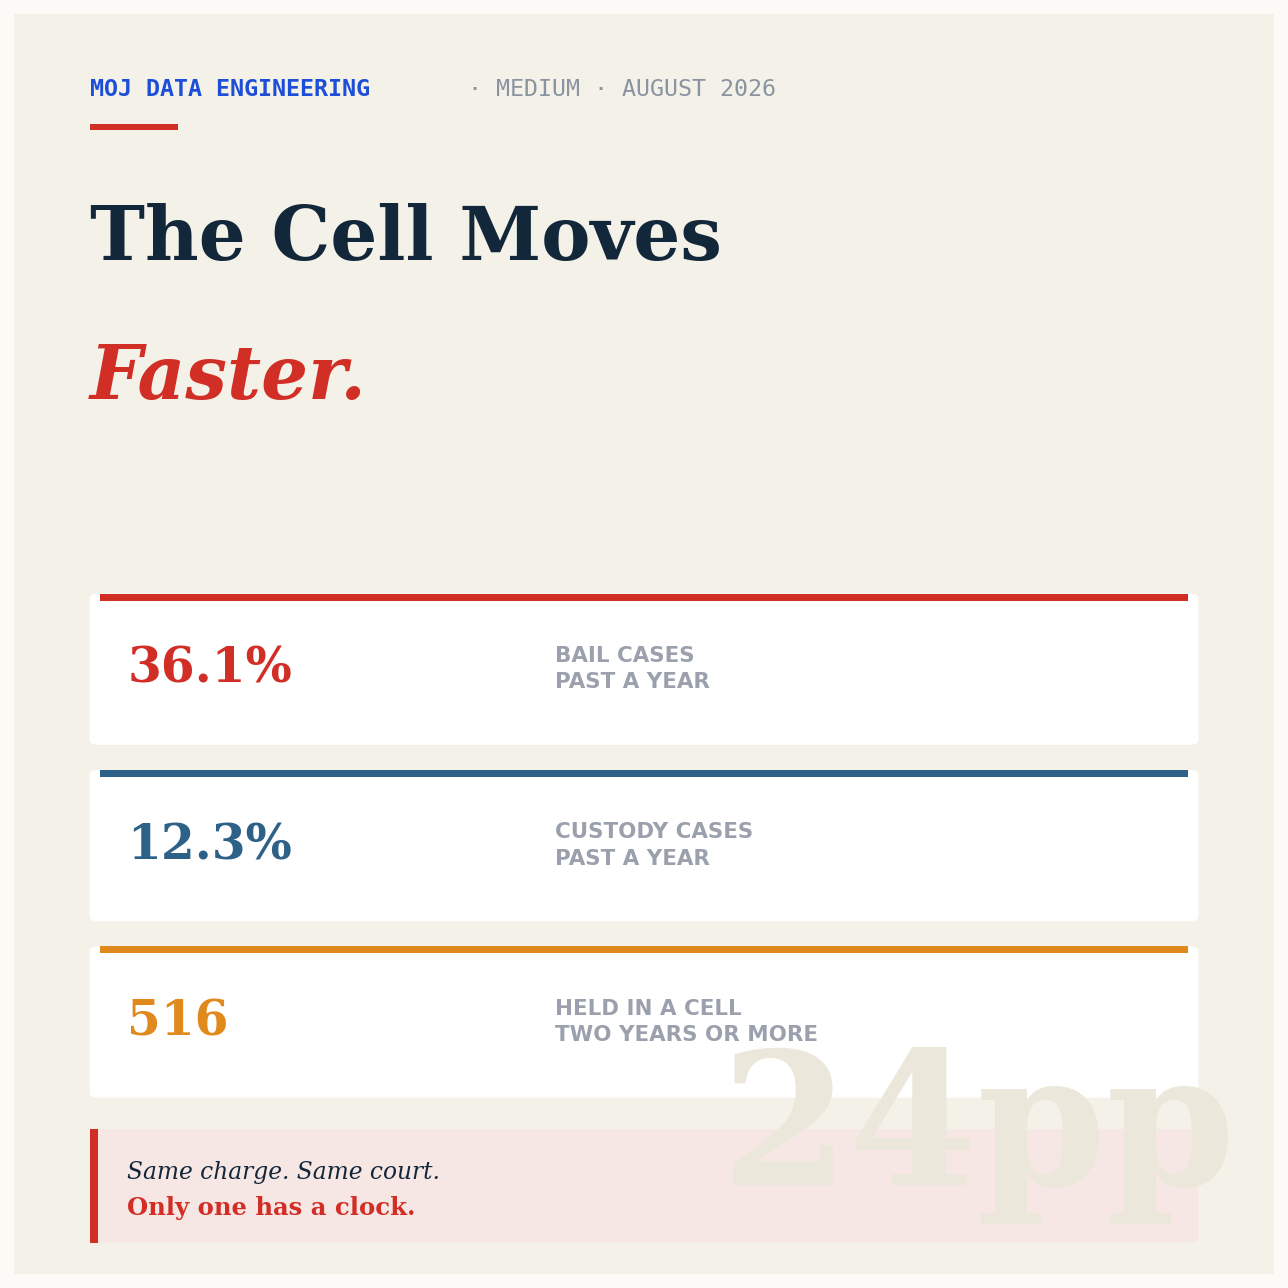

cards saved.


In [11]:
def rrect(ax,x,y,w,h,fc,rad=0.6,z=1):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={rad}",fc=fc,ec="none",lw=0,zorder=z,mutation_aspect=0.55))
def card(square=False):
    if square: fig=plt.figure(figsize=(9,9),dpi=140); W,H=100,100
    else:      fig=plt.figure(figsize=(12,6.3),dpi=150); W,H=100,52.6
    ax=fig.add_axes([0,0,1,1]); ax.axis("off"); ax.set_xlim(0,W); ax.set_ylim(0,H)
    ax.add_patch(Rectangle((0,0),W,H,fc=CREAM,zorder=0)); top=H-6
    ax.text(W-3,4,"24pp",fontsize=95 if square else 78,fontweight="bold",color="#ECE7DB",ha="right",va="bottom",family=SERIF)
    ax.text(6,top,"MOJ DATA ENGINEERING",fontsize=12,color=ROYAL,family=MONO,fontweight="bold",va="center")
    ax.text(6+(30 if square else 26),top,"\u00b7 MEDIUM \u00b7 AUGUST 2026",fontsize=12,color=MUTED,family=MONO,va="center")
    ax.add_patch(Rectangle((6,top-3.2),7,0.5,fc=RED,zorder=2)); ty=top-9
    ax.text(6,ty,"The Cell Moves",fontsize=38 if square else 32,color=INK,family=SERIF,fontweight="bold",va="top")
    ax.text(6,ty-(11 if square else 8.5),"Faster.",fontsize=38 if square else 32,color=RED,family=SERIF,fontweight="bold",style="italic",va="top")
    if square: cx,cw,ys,ch=6,88,[42,28,14],12
    else:      cx,cw,ys,ch=54,42,[34,20,6],12
    for (num,col,l1,l2),cy in zip([("36.1%",RED,"BAIL CASES","PAST A YEAR"),("12.3%",STEEL,"CUSTODY CASES","PAST A YEAR"),
        ("516",ORANGE,"HELD IN A CELL","TWO YEARS OR MORE")],ys):
        rrect(ax,cx,cy,cw,ch,WHITE,rad=0.7,z=2); ax.add_patch(Rectangle((cx+0.8,cy+ch-0.55),cw-1.6,0.55,fc=col,zorder=3))
        ax.text(cx+3,cy+ch/2,num,fontsize=25,color=col,family=SERIF,fontweight="bold",va="center",zorder=4)
        ax.text(cx+cw*0.42,cy+ch/2,f"{l1}\n{l2}",fontsize=11 if square else 10.5,color=LABEL,family=SANS,fontweight="bold",va="center",linespacing=1.4,zorder=4)
    qx,qy,qw,qh=(6,2.5,88,9) if square else (6,7,44,14)
    rrect(ax,qx,qy,qw,qh,PINK,rad=0.6,z=1); ax.add_patch(Rectangle((qx,qy),0.7,qh,fc=RED,zorder=3))
    ax.text(qx+3,qy+qh*0.62,"Same charge. Same court.",fontsize=12 if square else 12.5,color=INK,style="italic",family=SERIF,va="center")
    ax.text(qx+3,qy+qh*0.30,"Only one has a clock.",fontsize=12.5 if square else 13,color=RED,fontweight="bold",family=SERIF,va="center")
    if not square:
        ax.text(6,2.6,"Yusuf Ismail",fontsize=12,color=INK,fontweight="bold",family=SANS,va="bottom")
        ax.text(6,1.2,"medium.com/@yusufismail_91982",fontsize=9.5,color=ROYAL,family=MONO,va="bottom")
        rrect(ax,84,1.2,12,3.2,INK,rad=0.5,z=3)
        ax.text(90,2.8,"READ ON MEDIUM \u2192",fontsize=8.5,color=WHITE,fontweight="bold",family=MONO,ha="center",va="center",zorder=4)
    tag="social_square" if square else "cover_landscape"
    fig.savefig(OUT/f"a2_{tag}.png",facecolor=CREAM); return fig
card(False); plt.show(); card(True); plt.show()
print("cards saved.")

---
### Article 2 visuals complete
Five PNGs in `articles/visuals/` (prefix `a2_`). The article embeds them by relative path.